In [ ]:
pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [41]:
df = pd.read_csv("/content/demand_forecasting.csv")

# data cleaning, encoding and handling null values

df.drop_duplicates(inplace = True)

for col in df:
  if df[col].dtype == "object":
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.drop(['Date', 'Store ID'], axis = 1, inplace = True)

columns = [df.columns[i] for i in range(len(df.columns))]

imputer = SimpleImputer(strategy="most_frequent")
for col in columns:
  if col in df:
    if df[col].dtype!= "object" and df[col].isnull().sum() > 0:
      df.fillna(df[col].mean(), inplace=True)
    else:
      imputer.fit(df[[col]])
      df[col] = imputer.transform(df[[col]])

df.drop_duplicates(inplace = True)

df.dropna(inplace = True)

y = df['Demand']
x = df.drop('Demand', axis = 1)

# smote = SMOTE()
# x = df

# x_resampled, y_resampled = smote.fit_resample(x, y)


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

print(f"""

AFTER SMOTE


df.shape : {df.shape}
x_train : {x_train.shape}
x_test : {x_test.shape}
y_train : {y_train.shape}
y_test : {y_test.shape}
""")



AFTER SMOTE


df.shape : (76000, 14)
x_train : (60800, 13)
x_test : (15200, 13)
y_train : (60800,)
y_test : (15200,)



In [42]:
print(df)

       Product ID  Category  Region  Inventory Level  Units Sold  \
0               0         1       1              195         102   
1               1         0       1              117         117   
2               2         0       1              247         114   
3               3         1       1              139          45   
4               4         3       1              152          65   
...           ...       ...     ...              ...         ...   
75995          15         4       1              233          63   
75996          16         4       1              137         115   
75997          17         0       1              197          44   
75998          18         2       1              125          58   
75999          19         4       1              126          63   

       Units Ordered   Price  Discount  Weather Condition  Promotion  \
0                252   72.72         5                  2          0   
1                249   80.16        15 

In [43]:
print(y_train)

42977     81
67352     88
41725    123
10724    111
56438    149
        ... 
37194    190
6265     146
54886    171
860      186
15795     64
Name: Demand, Length: 60800, dtype: int64


In [44]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    median_absolute_error,
    explained_variance_score  )

xgb_model = XGBRegressor(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    objective='reg:squarederror',
    tree_method='auto')

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

# accuracy_scores = accuracy_score(y_test, y_pred)
# precision_scores = precision_score(y_test, y_pred)
# recall_scores = recall_score(y_test, y_pred)
# f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

# print(f"""
# Accuracy Score : {accuracy_scores}
# Precision Score : {precision_scores}
# Recall Score : {recall_scores}
# F1 Score : {f1_scores} """)

r2_score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 Score: {r2_score}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

R2 Score: 0.8923482894897461
Mean Absolute Error: 11.733119010925293
Mean Squared Error: 237.75051879882812


In [33]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# # Compute the confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# # Display the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass']) # Assuming binary classification for 'liked'
# disp.plot(cmap=plt.cm.Blues)
# plt.xlabel('Predicted student data')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.show()

In [36]:
# print(classification_report(y_test, y_pred))

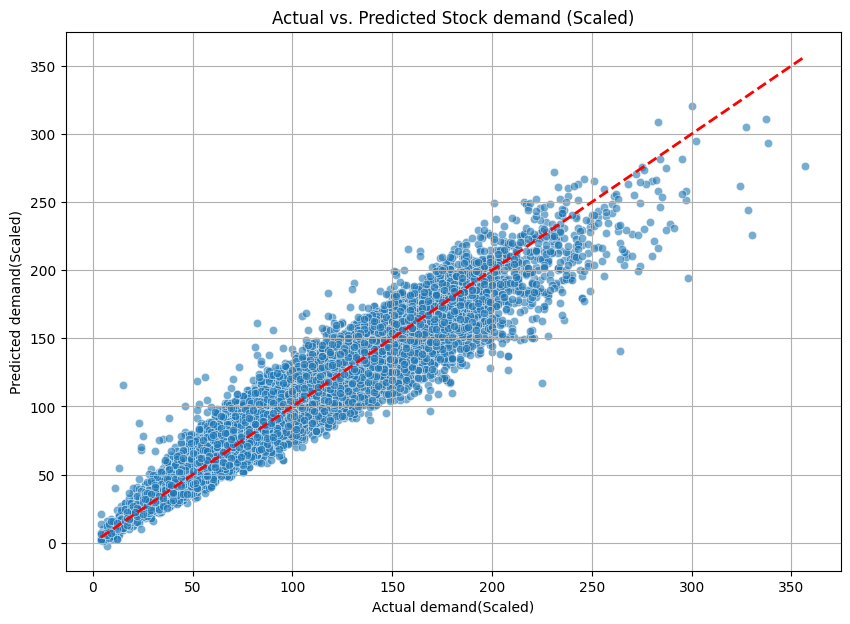

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted Stock demand (Scaled)')
plt.xlabel('Actual demand(Scaled)')
plt.ylabel('Predicted demand(Scaled)')
plt.grid(True)
plt.show()

In [48]:
import joblib
if joblib.dump(xgb_model, 'demand forcasting.pkl'):
  print("model saved")

model saved
